# LangGraph and LangSmith - Agentic RAG Powered by LangChain

In the following notebook we'll complete the following tasks:

- 🤝 Breakout Room #1:
  1. Install required libraries
  2. Set Environment Variables
  3. Creating our Tool Belt
  4. Creating Our State
  5. Creating and Compiling A Graph!

- 🤝 Breakout Room #2:
  1. Evaluating the LangGraph Application with LangSmith
  2. Adding Helpfulness Check and "Loop" Limits
  3. LangGraph for the "Patterns" of GenAI

# 🤝 Breakout Room #1

## Part 1: LangGraph - Building Cyclic Applications with LangChain

LangGraph is a tool that leverages LangChain Expression Language to build coordinated multi-actor and stateful applications that includes cyclic behaviour.

### Why Cycles?

In essence, we can think of a cycle in our graph as a more robust and customizable loop. It allows us to keep our application agent-forward while still giving the powerful functionality of traditional loops.

Due to the inclusion of cycles over loops, we can also compose rather complex flows through our graph in a much more readable and natural fashion. Effectively allowing us to recreate application flowcharts in code in an almost 1-to-1 fashion.

### Why LangGraph?

Beyond the agent-forward approach - we can easily compose and combine traditional "DAG" (directed acyclic graph) chains with powerful cyclic behaviour due to the tight integration with LCEL. This means it's a natural extension to LangChain's core offerings!

## Task 1:  Dependencies

We'll first install all our required libraries.

> NOTE: If you're running this locally - please skip this step.

In [1]:
#!pip install -qU langchain langchain_openai langchain-community langgraph arxiv

## Task 2: Environment Variables

We'll want to set both our OpenAI API key and our LangSmith environment variables.

In [2]:
import os
import getpass
from dotenv import load_dotenv

load_dotenv()

def set_api_key_if_not_present(key_name, prompt_message):
    if key_name not in os.environ or not os.environ[key_name]:
        os.environ[key_name] = getpass.getpass(prompt_message)

set_api_key_if_not_present("OPENAI_API_KEY", "OpenAI API Key:")

In [3]:
set_api_key_if_not_present("TAVILY_API_KEY", "TAVILY_API_KEY:")

In [4]:
from uuid import uuid4

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"AIE6 - LangGraph - {uuid4().hex[0:8]}"
set_api_key_if_not_present("LANGCHAIN_API_KEY", "LangSmith API Key:")

In [56]:
from IPython.display import display, Markdown
from langchain_core.messages import AIMessage
from langchain_core.runnables import RunnableSerializable
from typing import Union, Dict, Any

def display_markdown(message : (str, AIMessage) ):
    """Display formatted Markdown text in a Jupyter notebook.
    
    Args:
        text (str): Markdown formatted text to display
    """
    if isinstance(message, AIMessage):
        display(Markdown(message.content))
    else:
        display(Markdown(message))
        
    return message

class MarkdownDisplayRunnable(RunnableSerializable):
    """A runnable that displays content as Markdown in a Jupyter notebook.
    
    Can be used in LCEL chains to display outputs.
    """
    
    def invoke(self, input: Union[str, AIMessage, Dict[str, Any]], config=None) -> Union[str, AIMessage, Dict[str, Any]]:
        """Display the input as Markdown and pass it through."""
        if isinstance(input, dict) and "output" in input:
            display_markdown(input["output"])
            return input
        else:
            display_markdown(input)
            return input    

## Task 3: Creating our Tool Belt

As is usually the case, we'll want to equip our agent with a toolbelt to help answer questions and add external knowledge.

There's a tonne of tools in the [LangChain Community Repo](https://github.com/langchain-ai/langchain/tree/master/libs/community/langchain_community/tools) but we'll stick to a couple just so we can observe the cyclic nature of LangGraph in action!

We'll leverage:

- [Tavily Search Results](https://github.com/langchain-ai/langchain/blob/master/libs/community/langchain_community/tools/tavily_search/tool.py)
- [Arxiv](https://github.com/langchain-ai/langchain/tree/master/libs/community/langchain_community/tools/arxiv)

#### 🏗️ Activity #1:

Please add the tools to use into our toolbelt.

> NOTE: Each tool in our toolbelt should be a method.

In [6]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools.arxiv.tool import ArxivQueryRun

tavily_tool = TavilySearchResults(max_results=5)

tool_belt = [
    tavily_tool,
    ArxivQueryRun(),
]

Just to demo what the two tools do, here's the `invoke()` for each:

In [7]:
for response in tavily_tool.invoke("What is the capital of France?"):
    print(response["url"])
    display_markdown(response["content"])


https://en.wikipedia.org/wiki/List_of_capitals_of_France


Find sources: "List of capitals of France" – news · newspapers · books · scholar · JSTOR (July 2012) (Learn how and when to remove this message)
This is a chronological list of capitals of France. The capital of France has been Paris since its liberation in 1944.[1]
Chronology[edit]
Tournai (before 486), current-day Belgium
Soissons (486–936)
Laon (936–987)
Paris (987–1419), the residence of the Kings of France, although they were consecrated at Reims. [...] Bordeaux (September 1914), the government was relocated from Paris to Bordeaux very briefly during World War I, when it was feared that Paris would soon fall into German hands. These fears were alleviated after the German Army was pushed back at the First Battle of the Marne.
Tours (10–13 June 1940), the city served as the temporary capital of France during World War II after the government fled Paris due to the German advance. [...] Paris (1789–1871), on 5 and 6 October 1789, a throng from Paris invaded the castle and forced the royal family to move back to Paris. The National Constituent Assembly followed the King to Paris soon afterward; Versailles lost its role of capital city.
Provisional seats of the government:
Versailles (1871), the French Third Republic established Versailles as its provisional seat of government in March 1871 after the Paris Commune took control of Paris.

https://home.adelphi.edu/~ca19535/page%204.html


Paris is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants). Paris has 2.234 million inhabitants end 2011.

https://en.wikipedia.org/wiki/Paris


Paris (French pronunciation: [paʁi] ⓘ) is the capital and largest city of France. With an estimated population of 2,048,472 residents in January 2025[3] in an area of more than 105 km2 (41 sq mi),[4] Paris is the fourth-most populous city in the European Union, the ninth-most populous city in Europe and the 30th most densely populated city in the world in 2022.[5] Since the 17th century, Paris has been one of the world's major centres of finance, diplomacy, commerce, culture, fashion, and [...] As the capital of France, Paris is the seat of France's national government. For the executive, the two chief officers each have their own official residences, which also serve as their offices. The President of the French Republic resides at the Élysée Palace.[122] The Prime Minister's seat is at the Hôtel Matignon.[123][124] Government ministries are located in various parts of the city, many near the Hôtel Matignon.[125] [...] Jump to content
Main menu
Search
Appearance
Donate
Create account
Log in
Personal tools
        Photograph your local culture, help Wikipedia and win!
Toggle the table of contents
Paris
279 languages
Article
Talk
Read
View source
View history
Tools
Coordinates: 48°51′24″N 2°21′8″E
From Wikipedia, the free encyclopedia
This article is about the capital city of France. For other uses, see Paris (disambiguation).
"Parisien" redirects here. For other uses, see Parisien (disambiguation).
Paris

https://www.britannica.com/place/Paris


Paris is the capital of what country?
Paris is the national capital of France.
News •
JD Vance will attend AI summit in Paris and Munich security conference in first overseas trip as VP • Feb. 4, 2025, 11:53 AM ET (AP) ...(Show more)
Film director found guilty of sexual assault in France’s first big #MeToo trial • Feb. 3, 2025, 9:20 AM ET (AP)
Gisèle Pelicot's ex-husband, imprisoned for raping and drugging her, now caught up in other cases • Jan. 30, 2025, 11:56 AM ET (AP) [...] Paris, city and capital of France, situated in the north-central part of the country. People were living on the site of the present-day city, located along the Seine River some 233 miles (375 km) upstream from the river’s mouth on the English Channel (La Manche), by about 7600 bce. The modern city has spread from the island (the Île de la Cité) and far beyond both banks of the Seine. [...] 7 of History's Most Notorious Serial Killers

Where Does the Name Europe Come From?

Inventors and Inventions of the Industrial Revolution

Causes of the Great Depression

10 Legendary Creatures from Around the World
Contents
Geography & Travel Cities & Towns Cities & Towns P-S

Paris; Eiffel Tower View of the Paris skyline from Montparnasse. (more)
Paris
national capital, France
Ask the Chatbot a Question
More Actions
Print
print Print
Please select which sections you would like to print:

https://www.britannica.com/place/France


The capital and by far the most important city of France is Paris, one of the world’s preeminent cultural and commercial centres. A majestic city known as the ville lumière, or “city of light,” Paris has often been remade, most famously in the mid-19th century under the command of Georges-Eugène, Baron Haussman, who was committed to Napoleon III’s vision of a modern city free of the choleric swamps and congested alleys of old, with broad avenues and a regular plan. Paris is now a sprawling [...] See article: flag of France
Audio File: Anthem of France (see article)
Head Of Government:
Prime minister: Michel Barnier
(Show more)
Capital:
Paris
(Show more)
Population:
(2025 est.) 66,607,000
(Show more)
Currency Exchange Rate:
1 USD equals 0.937 euro
(Show more)
Head Of State:
President: Emmanuel Macron
(Show more)
Form Of Government:
republic with two legislative houses (Parliament; Senate [348], National Assembly [577])
(Show more)
Official Language:
French
(Show more) [...] Are you a student?
Get a special academic rate on Britannica Premium.
Subscribe
Among France’s other major cities are Lyon, located along an ancient Rhône valley trade route linking the North Sea and the Mediterranean; Marseille, a multiethnic port on the Mediterranean founded as an entrepôt for Greek and Carthaginian traders in the 6th century bce; Nantes, an industrial centre and deepwater harbour along the Atlantic coast; and Bordeaux, located in southwestern France along the Garonne River.

In [8]:
display_markdown( tool_belt[1].invoke("What is the Koopman operator?")  )

Published: 2001-05-23
Title: On Koopman-von Neumann Waves
Authors: D. Mauro
Summary: In this paper we study the classical Hilbert space introduced by Koopman and
von Neumann in their operatorial formulation of classical mechanics. In
particular we show that the states of this Hilbert space do not spread,
differently than what happens in quantum mechanics. The role of the phases
associated to these classical "wave functions" is analyzed in details. In this
framework we also perform the analog of the two-slit experiment and compare it
with the quantum case.

Published: 2003-06-05
Title: On Koopman-von Neumann Waves II
Authors: E. Gozzi, D. Mauro
Summary: In this paper we continue the study, started in [1], of the operatorial
formulation of classical mechanics given by Koopman and von Neumann (KvN) in
the Thirties. In particular we show that the introduction of the KvN Hilbert
space of complex and square integrable "wave functions" requires an enlargement
of the set of the observables of ordinary classical mechanics. The possible
role and the meaning of these extra observables is briefly indicated in this
work. We also analyze the similarities and differences between non selective
measurements and two-slit experiments in classical and quantum mechanics.

Published: 2001-11-14
Title: Minimal Coupling in Koopman-von Neumann Theory
Authors: E. Gozzi, D. Mauro
Summary: Classical mechanics (CM), like quantum mechanics (QM), can have an
operatorial formulation. This was pioneered by Koopman and von Neumann (KvN) in
the 30's. They basically formalized, via the introduction of a classical
Hilbert space, earlier work of Liouville who had shown that the classical time
evolution can take place via an operator, nowadays known as the Liouville
operator. In this paper we study how to perform the coupling of a point
particle to a gauge field in the KvN version of CM. So we basically implement
at the classical operatorial level the analog of the minimal coupling of QM. We
show that, differently than in QM, not only the momenta but also other
variables have to be coupled to the gauge field. We also analyze in details how
the gauge invariance manifests itself in the Hilbert space of KvN and indicate
the differences with QM. As an application of the KvN method we study the
Landau problem proving that there are many more degeneracies at the classical
operatorial level than at the quantum one. As a second example we go through
the Aharonov-Bohm phenomenon showing that, at the quantum level, this
phenomenon manifests its effects on the spectrum of the quantum Hamiltonian
while at the classical level there is no effect whatsoever on the spectrum of
the Liouville operator.

### Model

Now we can set-up our model! We'll leverage the familiar OpenAI model suite for this example - but it's not *necessary* to use with LangGraph. LangGraph supports all models - though you might not find success with smaller models - as such, they recommend you stick with:

- OpenAI's GPT-3.5 and GPT-4
- Anthropic's Claude
- Google's Gemini

> NOTE: Because we're leveraging the OpenAI function calling API - we'll need to use OpenAI *for this specific example* (or any other service that exposes an OpenAI-style function calling API.

In [9]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-4o", temperature=0)

Now that we have our model set-up, let's "put on the tool belt", which is to say: We'll bind our LangChain formatted tools to the model in an OpenAI function calling format.

In [10]:
model = model.bind_tools(tool_belt)

#### ❓ Question #1:

How does the model determine which tool to use?

#### ❗ Answer #1:

Model relies on the tool description to identify whether a particular tool
is relevant to the user's query. For example, the tools we specified above 
have the following descriptions:

In [11]:
for tool in tool_belt:
    display_markdown(f"  - **{tool.name}**: {tool.description}")


  - **tavily_search_results_json**: A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. Input should be a search query.

  - **arxiv**: A wrapper around Arxiv.org Useful for when you need to answer questions about Physics, Mathematics, Computer Science, Quantitative Biology, Quantitative Finance, Statistics, Electrical Engineering, and Economics from scientific articles on arxiv.org. Input should be a search query.

Now, importantly, the model itself does not call the tool.
Rather, the model formulates a JSON packet that contains inputs for the tool.
The function call (for each tool) has to happen in a separate LangGraph node.


## Task 4: Putting the State in Stateful

Earlier we used this phrasing:

`coordinated multi-actor and stateful applications`

So what does that "stateful" mean?

To put it simply - we want to have some kind of object which we can pass around our application that holds information about what the current situation (state) is. Since our system will be constructed of many parts moving in a coordinated fashion - we want to be able to ensure we have some commonly understood idea of that state.

LangGraph leverages a `StatefulGraph` which uses an `AgentState` object to pass information between the various nodes of the graph.

There are more options than what we'll see below - but this `AgentState` object is one that is stored in a `TypedDict` with the key `messages` and the value is a `Sequence` of `BaseMessages` that will be appended to whenever the state changes.

Let's think about a simple example to help understand exactly what this means (we'll simplify a great deal to try and clearly communicate what state is doing):

1. We initialize our state object:
  - `{"messages" : []}`
2. Our user submits a query to our application.
  - New State: `HumanMessage(#1)`
  - `{"messages" : [HumanMessage(#1)}`
3. We pass our state object to an Agent node which is able to read the current state. It will use the last `HumanMessage` as input. It gets some kind of output which it will add to the state.
  - New State: `AgentMessage(#1, additional_kwargs {"function_call" : "WebSearchTool"})`
  - `{"messages" : [HumanMessage(#1), AgentMessage(#1, ...)]}`
4. We pass our state object to a "conditional node" (more on this later) which reads the last state to determine if we need to use a tool - which it can determine properly because of our provided object!

In [12]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
import operator
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
  messages: Annotated[list, add_messages]

## Task 5: It's Graphing Time!

Now that we have state, and we have tools, and we have an LLM - we can finally start making our graph!

Let's take a second to refresh ourselves about what a graph is in this context.

Graphs, also called networks in some circles, are a collection of connected objects.

The objects in question are typically called nodes, or vertices, and the connections are called edges.

Let's look at a simple graph.

![image](https://i.imgur.com/2NFLnIc.png)

Here, we're using the coloured circles to represent the nodes and the yellow lines to represent the edges. In this case, we're looking at a fully connected graph - where each node is connected by an edge to each other node.

If we were to think about nodes in the context of LangGraph - we would think of a function, or an LCEL runnable.

If we were to think about edges in the context of LangGraph - we might think of them as "paths to take" or "where to pass our state object next".

Let's create some nodes and expand on our diagram.

> NOTE: Due to the tight integration with LCEL - we can comfortably create our nodes in an async fashion!

In [13]:
from langgraph.prebuilt import ToolNode

def call_model(state):
  messages = state["messages"]
  response = model.invoke(messages)
  return {"messages" : [response]}

tool_node = ToolNode(tool_belt)

Now we have two total nodes. We have:

- `call_model` is a node that will...well...call the model
- `tool_node` is a node which can call a tool

Let's start adding nodes! We'll update our diagram along the way to keep track of what this looks like!


In [14]:
from langgraph.graph import StateGraph, END

uncompiled_graph = StateGraph(AgentState)

uncompiled_graph.add_node("agent", call_model)
uncompiled_graph.add_node("action", tool_node)

Let's look at what we have so far:

![image](https://i.imgur.com/md7inqG.png)

Next, we'll add our entrypoint. All our entrypoint does is indicate which node is called first.

In [15]:
uncompiled_graph.set_entry_point("agent")

![image](https://i.imgur.com/wNixpJe.png)

Now we want to build a "conditional edge" which will use the output state of a node to determine which path to follow.

We can help conceptualize this by thinking of our conditional edge as a conditional in a flowchart!

Notice how our function simply checks if there is a "function_call" kwarg present.

Then we create an edge where the origin node is our agent node and our destination node is *either* the action node or the END (finish the graph).

It's important to highlight that the dictionary passed in as the third parameter (the mapping) should be created with the possible outputs of our conditional function in mind. In this case `should_continue` outputs either `"end"` or `"continue"` which are subsequently mapped to the action node or the END node.

In [16]:
def should_continue(state):
  last_message = state["messages"][-1]

  if last_message.tool_calls:
    return "action"

  return END

uncompiled_graph.add_conditional_edges(
    "agent",
    should_continue
)

> So the API for `add_conditional_edges` uses a `Callable` (as above) or
> `Runnable` instead of the second node (compared to `add_edge`). This means
> that we could potentially have another LLM processing the tool call request
> and sending it to an appropriate function.

Let's visualize what this looks like.

![image](https://i.imgur.com/8ZNwKI5.png)

Finally, we can add our last edge which will connect our action node to our agent node. This is because we *always* want our action node (which is used to call our tools) to return its output to our agent!

In [17]:
uncompiled_graph.add_edge("action", "agent")

Let's look at the final visualization.

![image](https://i.imgur.com/NWO7usO.png)

All that's left to do now is to compile our workflow - and we're off!

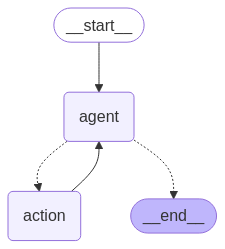

In [18]:
compiled_graph = uncompiled_graph.compile()
compiled_graph
compiled_graph.invoke()

#### ❓ Question #2:

Is there any specific limit to how many times we can cycle?

If not, how could we impose a limit to the number of cycles?

#### ❗ Answer #2:

The default recursion limit is set to 25 super-steps (sequential executions
of nodes).
It can be changed during invocation by passing kwarg 
`config={"recursion_limit" : 5} ` or whatever number we need

https://github.com/langchain-ai/langgraph/blob/main/docs/docs/concepts/low_level.md#recursion-limit

## Using Our Graph

Now that we've created and compiled our graph - we can call it *just as we'd call any other* `Runnable`!

Let's try out a few examples to see how it fairs:

In [21]:
from langchain_core.messages import HumanMessage

inputs = {"messages" : [HumanMessage(content="Who is the current captain of the Winnipeg Jets?")]}

async for chunk in compiled_graph.astream(inputs, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        print(values["messages"])
        for msg in values["messages"]:
            display_markdown(msg.content)
        print("\n\n")

Receiving update from node: 'agent'
[AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_GfoGujJL1Zx1qlPUeTZ7ZOq0', 'function': {'arguments': '{"query":"current captain of the Winnipeg Jets 2023"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 162, 'total_tokens': 189, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_d8864f8b6b', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-8a14f15b-bbfc-4f43-8931-7a66daea6c12-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current captain of the Winnipeg Jets 2023'}, 'id': 'call_GfoGujJL1Zx1qlPUeTZ7ZOq0', 'type': 'tool_call'}], usage_metadata={'input_tokens': 162, 'output_t




Receiving update from node: 'action'
[ToolMessage(content='[{"url": "https://www.hockey-reference.com/teams/WPG/2024.html", "content": "via Sports Logos.net\\n\\nAbout logos\\n\\n2023-24\\nWinnipeg Jets\\nRoster and Statistics\\n\\nRecord: 52-24-6 (110 points), Finished 2nd in NHL\xa0Central Division\\t\xa0(Schedule and Results)\\n\\nCoach: Rick Bowness (52-24-6)\\n\\nCaptain:\\nAdam Lowry\\n\\nPrimary Arena: Canada Life Centre\\n\\nGoals For: 259 (15th of 32), Goals Against: 198 (1st of 32)\\n\\tSRS: 0.69 (4th of 32),\xa0\\n\\tSOS: -0.04 (29th of 32)\\n\\nPlayoffs:Lost First Round (4-1) to Colorado Avalanche\\n\\nPreseason Odds: Stanley Cup +5000; O/U: 91.5\\n\\nOn this page: [...] 4 | Josh Morrissey | 28 | D | 5 | 3 | 1 | 4 | -3 | 2 | 1 | 2 | 0 | 0 | 0 | 1 | 0 | 12 | 25.0 | 28 | 122:55 | 24:35 | 0 | 0 |  | 12 | 4 | 2 | 2 | \\n5 | Brenden Dillon | 33 | D | 3 | 0 | 3 | 3 | 1 | 4 | 0 | 0 | 0 | 0 | 3 | 0 | 0 | 1 | 0.0 | 9 | 63:13 | 21:04 | 0 | 0 |  | 6 | 12 | 0 | 0 | \\n6 | Tyler Toff

[{"url": "https://www.hockey-reference.com/teams/WPG/2024.html", "content": "via Sports Logos.net\n\nAbout logos\n\n2023-24\nWinnipeg Jets\nRoster and Statistics\n\nRecord: 52-24-6 (110 points), Finished 2nd in NHL Central Division\t (Schedule and Results)\n\nCoach: Rick Bowness (52-24-6)\n\nCaptain:\nAdam Lowry\n\nPrimary Arena: Canada Life Centre\n\nGoals For: 259 (15th of 32), Goals Against: 198 (1st of 32)\n\tSRS: 0.69 (4th of 32), \n\tSOS: -0.04 (29th of 32)\n\nPlayoffs:Lost First Round (4-1) to Colorado Avalanche\n\nPreseason Odds: Stanley Cup +5000; O/U: 91.5\n\nOn this page: [...] 4 | Josh Morrissey | 28 | D | 5 | 3 | 1 | 4 | -3 | 2 | 1 | 2 | 0 | 0 | 0 | 1 | 0 | 12 | 25.0 | 28 | 122:55 | 24:35 | 0 | 0 |  | 12 | 4 | 2 | 2 | \n5 | Brenden Dillon | 33 | D | 3 | 0 | 3 | 3 | 1 | 4 | 0 | 0 | 0 | 0 | 3 | 0 | 0 | 1 | 0.0 | 9 | 63:13 | 21:04 | 0 | 0 |  | 6 | 12 | 0 | 0 | \n6 | Tyler Toffoli | 31 | C | 5 | 2 | 0 | 2 | -2 | 0 | 2 | 0 | 0 | 0 | 0 | 0 | 0 | 8 | 25.0 | 18 | 70:23 | 14:05 | 4 | 1 | 80.0 | 2 | 8 | 0 | 1 | [...] 1 | Mark Scheifele | 30 | C | 5 | 8 | 3 | 11 | 0 | -6 | \n2 | Kyle Connor | 27 | LW | 5 | 9 | 3 | 8 | 0 | -2 | \n3 | Gabriel Vilardi | 24 | C | 5 | 8 | 3 | 9 | 0 | -4 | \n4 | Josh Morrissey | 28 | D | 5 | 8 | 3 | 8 | 0 | -3 | \n5 | Brenden Dillon | 33 | D | 3 | 5 | 0 | 6 | 2 | 1 | \n6 | Nino Niederreiter | 31 | RW | 5 | 2 | 0 | 7 | 0 | -5 | \n7 | Mason Appleton | 28 | C | 5 | 3 | 0 | 7 | 0 | -4 | \n8 | Tyler Toffoli | 31 | C | 5 | 2 | 0 | 4 | 0 | -2 |"}, {"url": "https://www.nytimes.com/athletic/4855976/2023/09/12/adam-lowry-jets-captain/", "content": "NHL\n\nJets name Adam Lowry as captain ahead of 2023-24 season: Why Winnipeg chose him\n\nThe Winnipeg Jets finally have a captain again. The team gave forward Adam Lowry the honor Tuesday, making him the third captain in franchise history since the Jets moved from Atlanta. Here’s what you need to know:\n\nWe’ll battle beside him any day 😤 pic.twitter.com/2eeP3tjtGh\n\n— Winnipeg Jets (@NHLJets) September 12, 2023\n\n\n\nThe Athletic’s instant analysis:\n\nWhy Lowry? [...] important, checking role. Still, if you need a superstar to be your team’s captain, Lowry isn’t it. — Ates [...] assist in five playoff games."}, {"url": "https://www.nhl.com/jets/player/adam-lowry-8476392", "content": "Adam Lowry was named captain of the Winnipeg Jets on Sept. 12, 2023, and at age 30 was planning to rely on his father, Dave Lowry."}, {"url": "https://en.wikipedia.org/wiki/2023%E2%80%9324_Winnipeg_Jets_season", "content": "2023–24Winnipeg Jets\nDivision | 2ndCentral\nConference | 2ndWestern\n2023–24 record | 52–24–6\nHome record | 27–11–3\nRoad record | 25–13–3\nGoals for | 259\nGoals against | 199\nTeam information\nGeneral manager | Kevin Cheveldayoff\nCoach | Rick Bowness(Oct. 11 – Oct. 23, Nov. 24 – Apr. 30)Scott Arniel(interim, Oct. 23 – Nov. 24)\nCaptain | Adam Lowry\nAlternate captains | Josh MorrisseyMark Scheifele\nArena | Canada Life Centre\nAverage attendance | 13,447[1] [...] vteWinnipeg Jets\nFormerly theAtlanta ThrashersFounded in1999Based inWinnipeg, Manitoba\nFranchise | TeamGeneral managersCoachesPlayersCaptainsDraft picksexpansion draftSeasonsCurrent season\nHistory | RecordsAward winnersBroadcasters\nPersonnel | Owner(s)True North Sports & Entertainment(Mark Chipman, chairman)General managerKevin CheveldayoffHead coachScott ArnielTeam captainAdam LowryCurrent roster\nArena | Canada Life Centre\nAffiliates | AHLManitoba MooseECHLNorfolk Admirals [...] Player | GP | G | A | Pts | +/− | PIM\nMark Scheifele | 74 | 25 | 47 | 72 | 19 | 57\nJosh Morrissey | 81 | 10 | 59 | 69 | 34 | 44\nKyle Connor | 65 | 34 | 27 | 61 | –6 | 6\nNikolaj Ehlers | 82 | 25 | 36 | 61 | 27 | 29\nCole Perfetti | 71 | 19 | 19 | 38 | 13 | 12\nVladislav Namestnikov | 78 | 11 | 26 | 37 | 17 | 37\nGabriel Vilardi | 47 | 22 | 14 | 36 | 11 | 14\nMason Appleton | 82 | 14 | 22 | 36 | 16 | 26\nAdam Lowry | 81 | 12 | 23 | 35 | 17 | 57\nNino Niederreiter | 77 | 18 | 16 | 34 | 12 | 34"}, {"url": "https://www.nhlpa.com/news/2-36227/jets-make-centre-adam-lowry-new-captain-third-to-wear-c-in-winnipeg-history", "content": "Lowry is the third Jets captain since the team moved from Atlanta in 2011. After going without a captain for the 2022-23 season, Winnipeg chose the rugged centre over alternate captains Josh Morrissey and Mark Scheifele to succeed Blake Wheeler and Andrew Ladd.\n\n“It’s pretty special,” Lowry said at a press conference held at Canada Life Centre. “The FaceTime to my mom and seeing her reaction, and just seeing how proud she was, it was extremely special. [...] \"It’s an important step and an exciting one. I think Adam really embodies a lot of what the city of Winnipeg is all about — hard work, honest, blue collar, and comes to work each and every day.”\n\nCheveldayoff believes that the Jets' newest captain will help usher in a new era.\n\n\"We believe the time is right for Adam Lowry to assume this role and set the standard for the way the Winnipeg Jets will move forward with new leadership and new purpose.”"}]




Receiving update from node: 'agent'
[AIMessage(content='The current captain of the Winnipeg Jets is Adam Lowry. He was named captain on September 12, 2023.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 2020, 'total_tokens': 2047, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1920}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_d8864f8b6b', 'finish_reason': 'stop', 'logprobs': None}, id='run-65af0ecd-5168-47e9-a839-726da32469ec-0', usage_metadata={'input_tokens': 2020, 'output_tokens': 27, 'total_tokens': 2047, 'input_token_details': {'audio': 0, 'cache_read': 1920}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]


The current captain of the Winnipeg Jets is Adam Lowry. He was named captain on September 12, 2023.

Let's look at what happened:

1. Our state object was populated with our request
2. The state object was passed into our entry point (agent node) and the agent node added an `AIMessage` to the state object and passed it along the conditional edge
3. The conditional edge received the state object, found the "tool_calls" `additional_kwarg`, and sent the state object to the action node
4. The action node added the response from the OpenAI function calling endpoint to the state object and passed it along the edge to the agent node
5. The agent node added a response to the state object and passed it along the conditional edge
6. The conditional edge received the state object, could not find the "tool_calls" `additional_kwarg` and passed the state object to END where we see it output in the cell above!

Now let's look at an example that shows a multiple tool usage - all with the same flow!

In [23]:
inputs = {"messages" : [HumanMessage(content="Search Arxiv for the QLoRA paper, then search each of the authors to find out what position they hold using Tavily!")]}

async for chunk in compiled_graph.astream(inputs, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"Receiving update from node: '{node}'")
        if node == "action":
          print(f"Tool Used: {values['messages'][0].name}")
      
        print(values["messages"])
        for msg in values["messages"]:
            display_markdown(msg.content)
      
        print("\n\n")

Receiving update from node: 'agent'
[AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_clGxhsgVkycwzkaUYuOKFmxZ', 'function': {'arguments': '{"query":"QLoRA"}', 'name': 'arxiv'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 179, 'total_tokens': 196, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_d8864f8b6b', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-7e433266-1804-478c-b50d-10b7fc6767e6-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'QLoRA'}, 'id': 'call_clGxhsgVkycwzkaUYuOKFmxZ', 'type': 'tool_call'}], usage_metadata={'input_tokens': 179, 'output_tokens': 17, 'total_tokens': 196, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'a




Receiving update from node: 'action'
Tool Used: arxiv
[ToolMessage(content='Published: 2023-05-23\nTitle: QLoRA: Efficient Finetuning of Quantized LLMs\nAuthors: Tim Dettmers, Artidoro Pagnoni, Ari Holtzman, Luke Zettlemoyer\nSummary: We present QLoRA, an efficient finetuning approach that reduces memory usage\nenough to finetune a 65B parameter model on a single 48GB GPU while preserving\nfull 16-bit finetuning task performance. QLoRA backpropagates gradients through\na frozen, 4-bit quantized pretrained language model into Low Rank\nAdapters~(LoRA). Our best model family, which we name Guanaco, outperforms all\nprevious openly released models on the Vicuna benchmark, reaching 99.3% of the\nperformance level of ChatGPT while only requiring 24 hours of finetuning on a\nsingle GPU. QLoRA introduces a number of innovations to save memory without\nsacrificing performance: (a) 4-bit NormalFloat (NF4), a new data type that is\ninformation theoretically optimal for normally distributed we

Published: 2023-05-23
Title: QLoRA: Efficient Finetuning of Quantized LLMs
Authors: Tim Dettmers, Artidoro Pagnoni, Ari Holtzman, Luke Zettlemoyer
Summary: We present QLoRA, an efficient finetuning approach that reduces memory usage
enough to finetune a 65B parameter model on a single 48GB GPU while preserving
full 16-bit finetuning task performance. QLoRA backpropagates gradients through
a frozen, 4-bit quantized pretrained language model into Low Rank
Adapters~(LoRA). Our best model family, which we name Guanaco, outperforms all
previous openly released models on the Vicuna benchmark, reaching 99.3% of the
performance level of ChatGPT while only requiring 24 hours of finetuning on a
single GPU. QLoRA introduces a number of innovations to save memory without
sacrificing performance: (a) 4-bit NormalFloat (NF4), a new data type that is
information theoretically optimal for normally distributed weights (b) double
quantization to reduce the average memory footprint by quantizing the
quantization constants, and (c) paged optimziers to manage memory spikes. We
use QLoRA to finetune more than 1,000 models, providing a detailed analysis of
instruction following and chatbot performance across 8 instruction datasets,
multiple model types (LLaMA, T5), and model scales that would be infeasible to
run with regular finetuning (e.g. 33B and 65B parameter models). Our results
show that QLoRA finetuning on a small high-quality dataset leads to
state-of-the-art results, even when using smaller models than the previous
SoTA. We provide a detailed analysis of chatbot performance based on both human
and GPT-4 evaluations showing that GPT-4 evaluations are a cheap and reasonable
alternative to human evaluation. Furthermore, we find that current chatbot
benchmarks are not trustworthy to accurately evaluate the performance levels of
chatbots. A lemon-picked analysis demonstrates where Guanaco fails compared to
ChatGPT. We release all of our models and code, including CUDA kernels for
4-bit training.

Published: 2024-05-27
Title: Accurate LoRA-Finetuning Quantization of LLMs via Information Retention
Authors: Haotong Qin, Xudong Ma, Xingyu Zheng, Xiaoyang Li, Yang Zhang, Shouda Liu, Jie Luo, Xianglong Liu, Michele Magno
Summary: The LoRA-finetuning quantization of LLMs has been extensively studied to
obtain accurate yet compact LLMs for deployment on resource-constrained
hardware. However, existing methods cause the quantized LLM to severely degrade
and even fail to benefit from the finetuning of LoRA. This paper proposes a
novel IR-QLoRA for pushing quantized LLMs with LoRA to be highly accurate
through information retention. The proposed IR-QLoRA mainly relies on two
technologies derived from the perspective of unified information: (1)
statistics-based Information Calibration Quantization allows the quantized
parameters of LLM to retain original information accurately; (2)
finetuning-based Information Elastic Connection makes LoRA utilizes elastic
representation transformation with diverse information. Comprehensive
experiments show that IR-QLoRA can significantly improve accuracy across LLaMA
and LLaMA2 families under 2-4 bit-widths, e.g., 4- bit LLaMA-7B achieves 1.4%
improvement on MMLU compared with the state-of-the-art methods. The significant
performance gain requires only a tiny 0.31% additional time consumption,
revealing the satisfactory efficiency of our IR-QLoRA. We highlight that
IR-QLoRA enjoys excellent versatility, compatible with various frameworks
(e.g., NormalFloat and Integer quantization) and brings general accuracy gains.
The code is available at https://github.com/htqin/ir-qlora.

Published: 2025-02-05
Title: Resource-Efficient & Effective Code Summarization
Authors: Saima Afrin, Joseph Call, Khai-Nguyen Nguyen, Oscar Chaparro, Antonio Mastropaolo
Summary: Code Language Models (CLMs) have demonstrated high effectiveness in
automating software engineering tasks such as bug fixing, code generation, and
code documentation. This 




Receiving update from node: 'agent'
[AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_8dME8YakQlAoe8XLW8rsxa9v', 'function': {'arguments': '{"query": "Tim Dettmers position"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': 'call_M1FBc51MGkuSYjdTbhPxpRP6', 'function': {'arguments': '{"query": "Artidoro Pagnoni position"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': 'call_YJ2aaRGs1aUS2NwWf634ec7o', 'function': {'arguments': '{"query": "Ari Holtzman position"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': 'call_tWH2lLzlwGC8Rax08B3h2Qr2', 'function': {'arguments': '{"query": "Luke Zettlemoyer position"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 109, 'prompt_tokens': 1149, 'total_tokens': 1258, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_




Receiving update from node: 'action'
Tool Used: tavily_search_results_json
[ToolMessage(content='[{"url": "https://ai2050.schmidtsciences.org/fellow/tim-dettmers/", "content": "Tim Dettmers is an Assistant Professor at Carnegie Mellon University and a Research Scientist at the Allen Institute for AI."}, {"url": "https://www.interconnects.ai/p/tim-dettmers", "content": "Tim Dettmers does not need an introduction for most people building open-source AI. If you are part of that minority, you’re in for a treat. Tim is the lead developer behind most of the open-source tools for quantization: QLoRA, bitsandbytes, 4 and 8 bit inference, and plenty more. He recently finished his Ph.D. at the University of Washington, is now a researcher at the Allen Institute for AI, and is starting as a professor at Carnegie Mellon University in fall of 2025. [...] Nathan Lambert [00:44:25]: You need to be in a privileged position to where boring things are impactful, which is like AI too. We are the only 

...

[{"url": "https://gocrimson.com/sports/mens-fencing/roster/artidoro-pagnoni/4374", "content": "Artidoro Pagnoni ; Class Senior ; Hometown Rome, Italy ; High School ; Position Epee ; Concentration."}, {"url": "https://artidoro.github.io/files/Artidoro_Pagnoni.pdf", "content": "403 Belmont Ave E, #706​ ARTIDORO PAGNONI​ (857) 209-1344 Seattle, WA, 98102​ https://artidoro.github.io/ ​ pagnoni.artidoro@gmail.com EDUCATION​ ​ ​ ​ ​ ​ ​ ​ ​ Seattle, WA​ University of Washington​ Fall 2021 – present ●​Ph.D. Student Computer Science & Engineering, Advisor: Luke Zettlemoyer ●​Research in NLP with focus on resource efficiency and improving LLM scaling trends. Pittsburgh, PA​ Carnegie Mellon University​ Fall 2019 - Summer 2021 ●​M.S. Language Technologies (MLT), Advisor: Yulia [...] National Swimming Team TEACHING & SERVICE Academic Reviewer​ ​ ●​ACL ARR 25 February, 24 February, 23 December, EMNLP 23, COLING 24, ACL 23, EMNLP 22, COLING 22 Teaching Assistant​ Harvard CS 1, UW CSE 573​ 2017, 2018, 2024 ●​Directed weekly sections for 20 students, held office hours, graded problem sets and advised groups on final projects AWARDS ●​Madrona Prize 2023 ​ ​ ​ ​ ​ SPORTS Varsity Team​ Fencing​ Fall 2014 - Spring 2016 ●​Starter on Harvard Fencing Varsity Team, 2015 Ivy League [...] Research Fellow​ Harvard - Cadence Design Systems​ June - August 2016 ●​Developed a new method to optimize and automate the design of the layout of Printed Circuit Boards Analyst, intern​ Lonsin Capital Hedge Fund​ May - June 2015 ●​Assessed companies’ distressed assets and debt, analyzed long term effects of bankruptcy and credit restructuring Marketing, intern​ Geely Auto, Chinese Owner of Volvo​ July - August 2015 ●​Participated to the organization of a new sponsorship deal with the Chinese"}, {"url": "https://www.linkedin.com/in/artidoro-pagnoni", "content": "PhD student in NLP at UW with Luke Zettlemoyer. MS at CMU. Software Engineer at Microsoft… · Experience: Meta · Education: University of Washington"}, {"url": "https://artidoro.github.io/", "content": "Artidoro Pagnoni\n\nPhD student in NLP at the University of Washington\n\nCiao!\n\nI am a final-year PhD student in Computer Science at the University of Washington, advised by Luke Zettlemoyer, and a visiting researcher at Meta. My research focuses on resource efficiency and improving LLM scaling trends. [...] Previously, I have also worked on sythetic data augmentation for improved controllability of generation systems, investigated language models’ reasoning and world modeling abilities, and evaluated their factual errors, as well as societal challenge associated with their use."}, {"url": "https://dblp.org/pid/223/9977", "content": "2010 – 2019\n\nview\n\nauthority control:\n\nexport record\n\ndblp key:\n\nask others\n\nshare record\n\npersistent URL:\n\nview\n\nexport record\n\ndblp key:\n\nask others\n\nshare record\n\npersistent URL:\n\nview\n\nexport record\n\ndblp key:\n\nask others\n\nshare record\n\npersistent URL:\n\nview\n\nexport record\n\ndblp key:\n\nask others\n\nshare record\n\npersistent URL:\n\nview\n\nexport record\n\ndblp key:\n\nask others\n\nshare record\n\npersistent URL:\n\nview\n\nexport record\n\ndblp key:\n\nask others\n\nshare record\n\npersistent URL:\n\nview [...] Scholar. [...] authority control:\n\nexport record\n\ndblp key:\n\nask others\n\nshare record\n\npersistent URL:\n\nview\n\nexport record\n\ndblp key:\n\nask others\n\nshare record\n\npersistent URL:\n\nview\n\nauthority control:\n\nexport record\n\ndblp key:\n\nask others\n\nshare record\n\npersistent URL:\n\nview\n\nauthority control:\n\nexport record\n\ndblp key:\n\nask others\n\nshare record\n\npersistent URL:\n\nview\n\nauthority control:\n\nexport record\n\ndblp key:\n\nask others\n\nshare record\n\npersistent URL:\n\nview\n\nauthority control:\n\nexport record"}]

[{"url": "https://en.wikipedia.org/wiki/Ari_Holtzman", "content": "Contents\n\nAri Holtzman\n\nAri Holtzman is a professor of Computer Science at the University of Chicago and an expert in the area of Natural language processing and Computational linguistics.[1] Previously, Holtzman was a PhD student at the University of Washington where he was advised by Luke Zettlemoyer. [...] In 2017, he was a member of the winning team for the inaugural Alexa Prize for developing a conversational AI system for the Amazon Alexa device.[2] Holtzman has made multiple contributions in the area of text generation and language models such as the introduction of nucleus sampling in 2019, his work on AI safety and neural fake news detection, and the fine-tuning of quantized large language models.[3][4]\n\nReferences"}, {"url": "https://assets.super.so/2d1d8546-a465-401d-b76b-e0891cd78c1e/files/d73a5ad4-7352-4202-a7dc-c18e3e1021d7/Holtzman_Ariel_Cover_Letter_UoChicago.pdf", "content": "Ari Holtzman 419 NE 71st St. Apt. 316 Seattle, WA 98115 I +1 650-228-6145 # ahai@cs.washington.edu m http://ariholtzman.com Faculty Hiring Committee The Department of Computer Science, University of Chicago November 26, 2022 Dear members of the Faculty Hiring Committee, I am writing to apply for a tenure-track faculty position in the Department of Computer Science at the University of Chicago. I am currently a Doctoral Candidate at the Paul G. Allen School of Computer Science & Engineering at [...] With generative models advancing at breakneck speed, the importance of thoughtful and timely scholarship addressing how models work and how we can control them has magnified. I believe the University of Chicago would be an ideal place to contribute to the local and broader academic community’s investigation.\nI look forward to your response. Thank you.\nSincerely, Ari Holtzman"}, {"url": "https://health.usnews.com/doctors/ari-holtzman-1189896", "content": "Ari J. Holtzman is an orthopedist in Tacoma, Washington and is affiliated with multiple hospitals in the area, including UW Medicine-Harborview Medical Center"}, {"url": "https://ariholtzman.com/", "content": "Ari Holtzman · Head of Conceptualization Lab · Assistant Professor at · Office: Searle 213 · I am actively looking for PhD students to apply through both UChicago"}, {"url": "https://x.com/universeinanegg/status/1843071998043562326", "content": "Job Opportunity Alert for Tenure - Track & Tenured Faculty Roles: Assistant Professor of Data Science https://apply.interfolio.com/153879"}]

[{"url": "https://ai.meta.com/people/1450721039196474/luke-zettlemoyer/", "content": "Luke Zettlemoyer is a research manager and site lead for FAIR Seattle. He is also a Professor in the Allen School of Computer Science & Engineering at the"}, {"url": "https://www.cs.washington.edu/people/faculty/luke-zettlemoyer/", "content": "Luke Zettlemoyer is a Professor in the Paul G. Allen School of Computer Science & Engineering at the University of Washington, and a Research Director at Meta."}, {"url": "https://homes.cs.washington.edu/~lsz/", "content": "Luke Zettlemoyer\n\nProfessor\nPaul G. Allen School of Computer Science & Engineering \nUniversity of Washington\n\nSenior Research Director\nMeta FAIR\nlsz@cs.washington.edu\nPlease read before emailing\n\nlsz@cs.washington.edu\nPlease read before emailing\n\nEmail:\n    \t  I am embarassed to admit that I get way too many emails to respond to them all. Appologies in advance if I do not respond. [...] I am a Professor in the Paul G. Allen School of Computer Science & Engineering at the University of Washington, and a Senior Research Director at Meta. My research focuses on empirical methods for natural language semantics, and involves designing machine learning algorithms, introducing new tasks and datasets, analyzing model performance, and, most recently, studying how to best develop self-supervision signals for pre-training. My honors include being elected as ACL President (2024), named an [...] Name (Role, Year; Thesis; co-Advisor; First Emplyment)\n Yoav Artzi (PhD, 2015; Situated Understanding and Learning of Natural Language; Assistant Professor, Cornell)"}, {"url": "https://openreview.net/profile?id=~Luke_Zettlemoyer1", "content": "Luke Zettlemoyer\n\nFull Professor, University of Washington\n\nResearcher, FAIR, Facebook\n\nResearcher, Informatics, Meta\n\nNames\n\n\n\nEmails\n\n\n\nPersonal Links\n\n\n\nCareer & Education History\n\n\n\nAdvisors, Relations & Conflicts\n\n\n\nExpertise\n\n\n\nPublications\n\n\n\nLoading...\n\nCo-Authors\n\n\n\nLoading...\n\nOpenReview is a long-term project to advance science through improved peer review with legal nonprofit status. We gratefully acknowledge the support of the OpenReview Sponsors. © 2025 OpenReview\n\nSend Feedback"}, {"url": "https://dblp.org/pid/21/6793", "content": "affiliation: University of Washington, School of Computer Science & Engineering, Seattle, WA, USA; award (2016): Presidential Early Career Award for"}]




Receiving update from node: 'agent'
[AIMessage(content='Here are the positions held by the authors of the QLoRA paper:\n\n1. **Tim Dettmers**: He is a Research Scientist at the Allen Institute for AI and an incoming Assistant Professor at Carnegie Mellon University. He is known for his work on quantization and deep learning.\n\n2. **Artidoro Pagnoni**: He is a final-year PhD student in Computer Science at the University of Washington, advised by Luke Zettlemoyer, and a visiting researcher at Meta. His research focuses on resource efficiency and improving LLM scaling trends.\n\n3. **Ari Holtzman**: He is an Assistant Professor of Computer Science at the University of Chicago. Previously, he was a PhD student at the University of Washington, where he was advised by Luke Zettlemoyer.\n\n4. **Luke Zettlemoyer**: He is a Professor in the Paul G. Allen School of Computer Science & Engineering at the University of Washington and a Senior Research Director at Meta. He is also a research man

Here are the positions held by the authors of the QLoRA paper:

1. **Tim Dettmers**: He is a Research Scientist at the Allen Institute for AI and an incoming Assistant Professor at Carnegie Mellon University. He is known for his work on quantization and deep learning.

2. **Artidoro Pagnoni**: He is a final-year PhD student in Computer Science at the University of Washington, advised by Luke Zettlemoyer, and a visiting researcher at Meta. His research focuses on resource efficiency and improving LLM scaling trends.

3. **Ari Holtzman**: He is an Assistant Professor of Computer Science at the University of Chicago. Previously, he was a PhD student at the University of Washington, where he was advised by Luke Zettlemoyer.

4. **Luke Zettlemoyer**: He is a Professor in the Paul G. Allen School of Computer Science & Engineering at the University of Washington and a Senior Research Director at Meta. He is also a research manager and site lead for FAIR Seattle.

#### 🏗️ Activity #2:

Please write out the steps the agent took to arrive at the correct answer.

In [46]:
import logging
logging.basicConfig(level=logging.INFO)  # or DEBUG


In [47]:
response = compiled_graph.invoke(inputs,stream_mode="updates", config={"verbose": True})


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:arxiv:Requesting page (first: True, try: 0): https://export.arxiv.org/api/query?search_query=QLoRA&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100
INFO:arxiv:Got first page: 78 of 78 total results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Here's the LangSmith trace:

![Image](./Screenshot%20from%202025-04-20%2023-24-09.png)

It demonstrates that the following sequence is executed:

1. Query is passed to the LLM
1. LLM requests QLoRA paper from arxiv
1. Response is passed to LLM
1. LLM requests, for each author, their position from Tavily
1. Response is passed back to LLM which generates the final answer.

# 🤝 Breakout Room #2

## Part 1: LangSmith Evaluator

### Pre-processing for LangSmith

To do a little bit more preprocessing, let's wrap our LangGraph agent in a simple chain.

In [57]:
def convert_inputs(input_object):
  return {"messages" : [HumanMessage(content=input_object["question"])]}

def parse_output(input_state):
  return input_state["messages"][-1].content

agent_chain = convert_inputs | compiled_graph | parse_output | display_markdown

In [58]:
agent_chain.invoke({"question" : "What is RAG?"})

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


RAG stands for Retrieval-Augmented Generation. It is a technique used in natural language processing (NLP) that combines retrieval-based methods with generative models to improve the quality and accuracy of generated text. Here's a brief overview of how it works:

1. **Retrieval**: In the first step, relevant documents or pieces of information are retrieved from a large corpus or database. This is typically done using a retrieval model that can efficiently search and rank documents based on their relevance to a given query or context.

2. **Augmentation**: The retrieved information is then used to augment the input to a generative model. This means that the generative model has access to additional context or knowledge that can help it produce more accurate and contextually appropriate responses.

3. **Generation**: Finally, a generative model, such as a transformer-based language model, uses the augmented input to generate a response or piece of text. The generative model can leverage the retrieved information to produce more informed and relevant outputs.

RAG is particularly useful in scenarios where the generative model needs access to up-to-date or domain-specific information that is not contained within its pre-trained parameters. By combining retrieval and generation, RAG can enhance the performance of tasks such as question answering, dialogue systems, and content creation.

"RAG stands for Retrieval-Augmented Generation. It is a technique used in natural language processing (NLP) that combines retrieval-based methods with generative models to improve the quality and accuracy of generated text. Here's a brief overview of how it works:\n\n1. **Retrieval**: In the first step, relevant documents or pieces of information are retrieved from a large corpus or database. This is typically done using a retrieval model that can efficiently search and rank documents based on their relevance to a given query or context.\n\n2. **Augmentation**: The retrieved information is then used to augment the input to a generative model. This means that the generative model has access to additional context or knowledge that can help it produce more accurate and contextually appropriate responses.\n\n3. **Generation**: Finally, a generative model, such as a transformer-based language model, uses the augmented input to generate a response or piece of text. The generative model can l

### Task 1: Creating An Evaluation Dataset

Just as we saw last week, we'll want to create a dataset to test our Agent's ability to answer questions.

In order to do this - we'll want to provide some questions and some answers. Let's look at how we can create such a dataset below.

```python
questions = [
    "What optimizer is used in QLoRA?",
    "What data type was created in the QLoRA paper?",
    "What is a Retrieval Augmented Generation system?",
    "Who authored the QLoRA paper?",
    "What is the most popular deep learning framework?",
    "What significant improvements does the LoRA system make?"
]

answers = [
    {"must_mention" : ["paged", "optimizer"]},
    {"must_mention" : ["NF4", "NormalFloat"]},
    {"must_mention" : ["ground", "context"]},
    {"must_mention" : ["Tim", "Dettmers"]},
    {"must_mention" : ["PyTorch", "TensorFlow"]},
    {"must_mention" : ["reduce", "parameters"]},
]
```

#### 🏗️ Activity #3:

Please create a dataset in the above format with at least 5 questions.

In [52]:
questions = [
    "What optimizer is used in QLoRA?",
    "What data type was created in the QLoRA paper?",
    "What is a Retrieval Augmented Generation system?",
    "Who authored the QLoRA paper?",
    "What is the most popular deep learning framework?",
    "What significant improvements does the LoRA system make?"
]

answers = [
    {"must_mention" : ["paged", "optimizer"]},
    {"must_mention" : ["NF4", "NormalFloat"]},
    {"must_mention" : ["ground", "context"]},
    {"must_mention" : ["Tim", "Dettmers"]},
    {"must_mention" : ["PyTorch", "TensorFlow"]},
    {"must_mention" : ["reduce", "parameters"]},
]

Now we can add our dataset to our LangSmith project using the following code which we saw last Thursday!

In [59]:
from langsmith import Client

client = Client()

dataset_name = f"Retrieval Augmented Generation - Evaluation Dataset - {uuid4().hex[0:8]}"

dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="Questions about the QLoRA Paper to Evaluate RAG over the same paper."
)

client.create_examples(
    inputs=[{"question" : q} for q in questions],
    outputs=answers,
    dataset_id=dataset.id,
)

{'example_ids': ['f11985c3-45b2-4320-bbef-d8c6e4aa3d7c',
  '60aae96d-903b-48d6-90ac-6a7c613a8b67',
  'dfe0ae29-2e7c-4647-938a-5b6a77d6084f',
  '48b213a4-82d4-4b59-97a2-d8c9ba909234',
  '41e4a5da-29fb-4feb-a063-408efe2364dd',
  '4e6662db-18a0-4963-9abc-3b827286250f'],
 'count': 6}

#### ❓ Question #3:

How are the correct answers associated with the questions?

> NOTE: Feel free to indicate if this is problematic or not

#### ❗ Answer #3:

I am not sure if the question here means in a programatic or semantic sense.

In the programmatic sense, the correct answer is associated with each question
by 1-1 association between elements in inputs list of dictionaries and outputs
list of dictionaries.

In the semantic sense, the correct answer is specified by "must mention" 
criterion. This may be problematic for more complex examples, as for some
questions two valid answers do not necessarily have to contain the same 
phrase.

For example, "reduce speed" and "slow down" mean the same thing, but do not 
contain common strings.


### Task 2: Adding Evaluators

Now we can add a custom evaluator to see if our responses contain the expected information.

We'll be using a fairly naive exact-match process to determine if our response contains *all* specific strings.

In [54]:
from langsmith.evaluation import EvaluationResult, run_evaluator
from langsmith.schemas import Run, Example

@run_evaluator
def must_mention(run:Run, example:Example) -> EvaluationResult:
    prediction = run.outputs.get("output") or ""
    required = example.outputs.get("must_mention") or []
    score = all(phrase in prediction for phrase in required)
    return EvaluationResult(key="must_mention", score=score)

#### ❓ Question #4:

What are some ways you could improve this metric as-is?

> NOTE: Alternatively you can suggest where gaps exist in this method.

We could convert to lower-case both the metric and matching patterns
since capitalizaton is likely secondary (and may legitimately vary).

### Task 3: Evaluating

All that is left to do is evaluate our agent's response!

In [60]:
experiment_results = client.evaluate(
    agent_chain,
    data=dataset_name,
    evaluators=[must_mention],
    experiment_prefix=f"RAG Pipeline - Evaluation - {uuid4().hex[0:4]}",
    metadata={"version": "1.0.0"},
)

View the evaluation results for experiment: 'RAG Pipeline - Evaluation - 3230-f297866b' at:
https://smith.langchain.com/o/d5aca770-e410-428e-97f9-497517327fbd/datasets/9b170f78-cdb8-4076-a17e-6541a2affd34/compare?selectedSessions=b2491adc-c911-4fc1-aa2b-b08345e2266b




0it [00:00, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:arxiv:Requesting page (first: True, try: 0): https://export.arxiv.org/api/query?search_query=LoRA+system+improvements&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100
INFO:arxiv:Got first page: 100 of 919207 total results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


The LoRA (Low-Rank Adaptation) system has made several significant improvements across different applications:

1. **Federated Learning**: In the context of federated learning, LoRA has been enhanced to improve communication efficiency. The "Federated LoRA with Sparse Communication" approach applies sparsity during communication, allowing clients to locally fine-tune the entire LoRA module. This method achieves performance comparable to dense LoRA with up to 10 times less communication, and also offers benefits in terms of handling heterogeneity and privacy.

2. **IoT Networks**: For IoT applications, LoRA networks have been designed to be more cost-effective and flexible. The "Open LoRa for IoT" system provides a feasible solution for building private LoRa networks, with an improved software architecture for the LoRa network server that enhances scalability and flexibility.

3. **Vision Applications**: In vision tasks, LoRA has been integrated into Large Multimodal Models (LMMs) to enhance their performance. The "VaLoRA" system uses an accuracy-aware LoRA adapter generation approach to enrich vision applications with domain-specific knowledge, improving both accuracy and efficiency.

These improvements highlight LoRA's versatility and effectiveness in enhancing communication efficiency, scalability, flexibility, and domain-specific performance across various fields.

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

A Retrieval Augmented Generation (RAG) system is a type of artificial intelligence model that combines retrieval-based and generation-based approaches to improve the quality and relevance of generated responses or content. Here's how it works:

1. **Retrieval Component**: This part of the system retrieves relevant information from a large corpus of documents or a database. It uses techniques similar to those in search engines to find documents or snippets that are most relevant to the input query or context.

2. **Generation Component**: Once the relevant information is retrieved, the generation component uses this information to produce a coherent and contextually appropriate response. This is typically done using a language model, such as a transformer-based model, which can generate human-like text.

3. **Integration**: The retrieved information is used to guide the generation process, ensuring that the output is not only fluent and coherent but also factually accurate and relevant to the user's query. This integration helps in overcoming the limitations of purely generative models, which might produce plausible but incorrect or irrelevant information.

RAG systems are particularly useful in applications where accuracy and relevance are critical, such as in question answering, customer support, and content creation. They leverage the strengths of both retrieval and generation to provide more reliable and informative outputs.

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:arxiv:Requesting page (first: True, try: 0): https://export.arxiv.org/api/query?search_query=QLoRA+paper&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100
INFO:arxiv:Got first page: 100 of 680999 total results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


The QLoRA paper titled "Accurate LoRA-Finetuning Quantization of LLMs via Information Retention" was authored by Haotong Qin, Xudong Ma, Xingyu Zheng, Xiaoyang Li, Yang Zhang, Shouda Liu, Jie Luo, Xianglong Liu, and Michele Magno.

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:arxiv:Requesting page (first: True, try: 0): https://export.arxiv.org/api/query?search_query=QLoRA+data+type&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100
INFO:arxiv:Got first page: 100 of 792043 total results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


The QLoRA paper introduced a new data type called "4-bit NormalFloat (NF4)," which is designed to be information theoretically optimal for normally distributed weights.

In [61]:
experiment_results

,inputs.question,outputs.output,error,reference.must_mention,feedback.must_mention,execution_time,example_id,id
0,What significant improvements does the LoRA sy...,The LoRA (Low-Rank Adaptation) system has made...,None,"[reduce, parameters]",False,4.784977,41e4a5da-29fb-4feb-a063-408efe2364dd,d364a015-cee1-4cdc-b1ac-2f850cf440ff
1,What is the most popular deep learning framework?,"In 2023, the most popular deep learning framew...",None,"[PyTorch, TensorFlow]",True,3.568107,48b213a4-82d4-4b59-97a2-d8c9ba909234,1e70fbb2-dbe4-458f-ae7e-6ce8641006d5
2,What optimizer is used in QLoRA?,"QLoRA uses ""paged optimizers"" to manage memory...",None,"[paged, optimizer]",True,2.244295,4e6662db-18a0-4963-9abc-3b827286250f,2a771d38-ad67-4e6f-82cf-fc4cfa76b3b9
3,What is a Retrieval Augmented Generation system?,A Retrieval Augmented Generation (RAG) system ...,None,"[ground, context]",False,3.104930,60aae96d-903b-48d6-90ac-6a7c613a8b67,299d343a-e5e2-4e4f-9fdb-4fc9b8053587
4,Who authored the QLoRA paper?,"The QLoRA paper titled ""Accurate LoRA-Finetuni...",None,"[Tim, Dettmers]",False,2.197066,dfe0ae29-2e7c-4647-938a-5b6a77d6084f,76bd2206-90b8-4118-b281-67e61192bab2
5,What data type was created in the QLoRA paper?,The QLoRA paper introduced a new data type cal...,None,"[NF4, NormalFloat]",True,2.218395,f11985c3-45b2-4320-bbef-d8c6e4aa3d7c,1dbce328-22da-4b71-96b6-dc0106e457c6


## Part 2: LangGraph with Helpfulness:

### Task 3: Adding Helpfulness Check and "Loop" Limits

Now that we've done evaluation - let's see if we can add an extra step where we review the content we've generated to confirm if it fully answers the user's query!

We're going to make a few key adjustments to account for this:

1. We're going to add an artificial limit on how many "loops" the agent can go through - this will help us to avoid the potential situation where we never exit the loop.
2. We'll add to our existing conditional edge to obtain the behaviour we desire.

First, let's define our state again - we can check the length of the state object, so we don't need additional state for this.

In [62]:
class AgentState(TypedDict):
  messages: Annotated[list, add_messages]

Now we can set our graph up! This process will be almost entirely the same - with the inclusion of one additional node/conditional edge!

#### 🏗️ Activity #5:

Please write markdown for the following cells to explain what each is doing.

> Marko: First, we define the graph and add an LLM-calling node and a tool-calling node.

In [63]:
graph_with_helpfulness_check = StateGraph(AgentState)

graph_with_helpfulness_check.add_node("agent", call_model)
graph_with_helpfulness_check.add_node("action", tool_node)

> Marko: Then, we add the entry point to the node "agent" so the human query
> is passed to it first.

In [64]:
graph_with_helpfulness_check.set_entry_point("agent")

> OK, this is now the conditional that defines where we're going 
> after LLM returns a response.
>


In [65]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

def tool_call_or_helpful(state):
  last_message = state["messages"][-1]

  if last_message.tool_calls:
    return "action"
  
  if len(state["messages"]) > 10:
    return "END"

  initial_query = state["messages"][0]
  final_response = state["messages"][-1]


  prompt_template = """\
  Given an initial query and a final response, determine if the final response 
  is extremely helpful or not. Please indicate helpfulness 
  with a 'Y' and unhelpfulness as an 'N'.

  Initial Query:
  {initial_query}

  Final Response:
  {final_response}"""

  prompt_template = PromptTemplate.from_template(prompt_template)

  helpfulness_check_model = ChatOpenAI(model="gpt-4")

  helpfulness_chain = prompt_template | helpfulness_check_model | StrOutputParser()

  helpfulness_response = helpfulness_chain.invoke({"initial_query" : initial_query.content, "final_response" : final_response.content})

  if "Y" in helpfulness_response:
    return "end"
  else:
    return "continue"

#### 🏗️ Activity #4:

Please write what is happening in our `tool_call_or_helpful` function!

> First, we check the last message to see if the tool call is requested. 
> This is just as before.
>
> Second, we exit the invocation by going to END  if the loop repetition has reached 10.
>
> If neither of those is the case, then we use the original query and the 
> last response to check how well the response matches the original query.
> We do this by formulating a new prompt sent to gpt-4 model in which
> we ask for a binary Y/N response of "helpfulness" of the query.
>
> A helpful response exits the chain.
> Unhelpful response moves to the "continue" node.

> Now we connect the possible results of the conditional:
> "continue" will call LLM (this is the "unhelpful" case)
> "action" will call the tool belt
> "end" will terminate the invokation.

In [66]:
graph_with_helpfulness_check.add_conditional_edges(
    "agent",
    tool_call_or_helpful,
    {
        "continue" : "agent",
        "action" : "action",
        "end" : END
    }
)

> Last edge routes all responses from "action" node to "agent" node.

In [67]:
graph_with_helpfulness_check.add_edge("action", "agent")

> We compile and display the graph now.

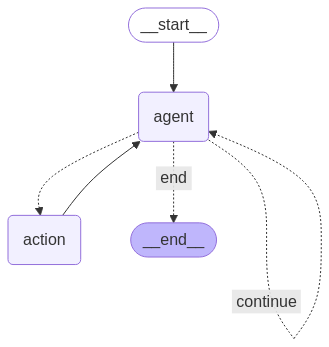

In [68]:
agent_with_helpfulness_check = graph_with_helpfulness_check.compile()

agent_with_helpfulness_check

> Now, let's ask the system a multi-part question and stream its response.

In [70]:
inputs = {"messages" : [HumanMessage(content="Related to machine learning, what is LoRA? Also, who is Tim Dettmers? Also, what is Attention?")]}

async for chunk in agent_with_helpfulness_check.astream(inputs, stream_mode="updates"):
    for node, values in chunk.items():
        display_markdown(f"Receiving update from node: '{node}'")
        print(values["messages"])
        display_markdown(values["messages"][-1].content)
        print("\n\n")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Receiving update from node: 'agent'

[AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_OUXT1ggX1wUUyPjWEWk1kd9s', 'function': {'arguments': '{"query": "LoRA machine learning"}', 'name': 'arxiv'}, 'type': 'function'}, {'id': 'call_NnPbtKDhGEyIEJWU30QdNXVj', 'function': {'arguments': '{"query": "Tim Dettmers"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': 'call_oZayyKXqA9XBtaBEDQDHZTeu', 'function': {'arguments': '{"query": "Attention mechanism in machine learning"}', 'name': 'arxiv'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 177, 'total_tokens': 250, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_6b6e24b474', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-ee1abb89-7e36-483f-88de-

INFO:arxiv:Requesting page (first: True, try: 0): https://export.arxiv.org/api/query?search_query=LoRA+machine+learning&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100
INFO:arxiv:Requesting page (first: True, try: 0): https://export.arxiv.org/api/query?search_query=Attention+mechanism+in+machine+learning&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100


INFO:arxiv:Got first page: 100 of 398832 total results
INFO:arxiv:Got first page: 100 of 2563362 total results


...

Published: 2022-03-27
Title: A General Survey on Attention Mechanisms in Deep Learning
Authors: Gianni Brauwers, Flavius Frasincar
Summary: Attention is an important mechanism that can be employed for a variety of
deep learning models across many different domains and tasks. This survey
provides an overview of the most important attention mechanisms proposed in the
literature. The various attention mechanisms are explained by means of a
framework consisting of a general attention model, uniform notation, and a
comprehensive taxonomy of attention mechanisms. Furthermore, the various
measures for evaluating attention models are reviewed, and methods to
characterize the structure of attention models based on the proposed framework
are discussed. Last, future work in the field of attention models is
considered.

Published: 2022-07-04
Title: Attention mechanisms for physiological signal deep learning: which attention should we take?
Authors: Seong-A Park, Hyung-Chul Lee, Chul-Woo Jung, Hyun-Lim Yang
Summary: Attention mechanisms are widely used to dramatically improve deep learning
model performance in various fields. However, their general ability to improve
the performance of physiological signal deep learning model is immature. In
this study, we experimentally analyze four attention mechanisms (e.g.,
squeeze-and-excitation, non-local, convolutional block attention module, and
multi-head self-attention) and three convolutional neural network (CNN)
architectures (e.g., VGG, ResNet, and Inception) for two representative
physiological signal prediction tasks: the classification for predicting
hypotension and the regression for predicting cardiac output (CO). We evaluated
multiple combinations for performance and convergence of physiological signal
deep learning model. Accordingly, the CNN models with the spatial attention
mechanism showed the best performance in the classification problem, whereas
the channel attention mechanism achieved the lowest error in the regression
problem. Moreover, the performance and convergence of the CNN models with
attention mechanisms were better than stand-alone self-attention models in both
problems. Hence, we verified that convolutional operation and attention
mechanisms are complementary and provide faster convergence time, despite the
stand-alone self-attention models requiring fewer parameters.

Published: 2018-10-17
Title: An Analysis of Attention Mechanisms: The Case of Word Sense Disambiguation in Neural Machine Translation
Authors: Gongbo Tang, Rico Sennrich, Joakim Nivre
Summary: Recent work has shown that the encoder-decoder attention mechanisms in neural
machine translation (NMT) are different from the word alignment in statistical
machine translation. In this paper, we focus on analyzing encoder-decoder
attention mechanisms, in the case of word sense disambiguation (WSD) in NMT
models. We hypothesize that attention mechanisms pay more attention to context
tokens when translating ambiguous words. We explore the attention distribution
patterns when translating ambiguous nouns. Counter-intuitively, we find that
attention mechanisms are likely to distribute more attention to the ambiguous
noun itself rather than context tokens, in comparison to other nouns. We
conclude that attention mechanism is not the main mechanism used by NMT models
to incorporate contextual information for WSD. The experimental results suggest
that NMT models learn to encode contextual information necessary for WSD in the
encoder hidden states. For the attention mechanism in Transformer models, we
reveal that the first few layers gradually learn to "align" source and target
tokens and the last few layers learn to extract features from the related but
unaligned context tokens.

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Receiving update from node: 'agent'

[AIMessage(content='### LoRA in Machine Learning\nLoRA, or Low-Rank Adaptation, is a method used for efficiently adapting large language models (LLMs) with minimal computational resources. It introduces auxiliary parameters for each layer to fine-tune pre-trained models, making it a popular parameter-efficient fine-tuning (PEFT) method. Recent advancements include KD-LoRA, which combines LoRA with knowledge distillation to reduce resource requirements while maintaining performance. LoRA-drop is another approach that prunes LoRA parameters based on output evaluation to further enhance efficiency.\n\n### Tim Dettmers\nTim Dettmers is a prominent figure in the AI community, known for his work in making deep learning accessible. He is an Assistant Professor at Carnegie Mellon University and a Research Scientist at the Allen Institute for AI. Dettmers has contributed significantly to the development of open-source tools for AI, particularly in quantization and efficient deep learning. His r

### LoRA in Machine Learning
LoRA, or Low-Rank Adaptation, is a method used for efficiently adapting large language models (LLMs) with minimal computational resources. It introduces auxiliary parameters for each layer to fine-tune pre-trained models, making it a popular parameter-efficient fine-tuning (PEFT) method. Recent advancements include KD-LoRA, which combines LoRA with knowledge distillation to reduce resource requirements while maintaining performance. LoRA-drop is another approach that prunes LoRA parameters based on output evaluation to further enhance efficiency.

### Tim Dettmers
Tim Dettmers is a prominent figure in the AI community, known for his work in making deep learning accessible. He is an Assistant Professor at Carnegie Mellon University and a Research Scientist at the Allen Institute for AI. Dettmers has contributed significantly to the development of open-source tools for AI, particularly in quantization and efficient deep learning. His research focuses on making large models accessible and includes projects like QLoRA and bitsandbytes.

### Attention Mechanism in Machine Learning
Attention mechanisms are crucial in deep learning models, allowing them to focus on specific parts of the input data. They are widely used across various domains to improve model performance. Attention mechanisms can be categorized into different types, such as squeeze-and-excitation, non-local, convolutional block attention module, and multi-head self-attention. These mechanisms help models, like CNNs, to better handle tasks such as word sense disambiguation in neural machine translation by focusing on relevant context tokens. Attention mechanisms are complementary to convolutional operations, providing faster convergence and improved performance.

### Task 4: LangGraph for the "Patterns" of GenAI

Let's ask our system about the 4 patterns of Generative AI:

1. Prompt Engineering
2. RAG
3. Fine-tuning
4. Agents

In [72]:
patterns = ["prompt engineering", "RAG", "fine-tuning", "LLM-based agents"]

In [74]:
for pattern in patterns:
  what_is_string = f"What is {pattern} and when did it break onto the scene??"
  inputs = {"messages" : [HumanMessage(content=what_is_string)]}
  messages = agent_with_helpfulness_check.invoke(inputs)
  display_markdown(what_is_string)
  display_markdown(messages["messages"][-1].content)
  print("\n\n")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


What is prompt engineering and when did it break onto the scene??

**Prompt Engineering: Definition**

Prompt engineering is the process of designing and refining input prompts to effectively guide the behavior of AI models. It involves crafting instructions or queries in natural language to elicit specific responses from generative AI tools, such as text, images, or other digital artifacts. This technique is crucial for improving the accuracy and effectiveness of AI outputs, minimizing biases, and enhancing the usability of AI-powered services. Prompt engineering is used across various applications, including content generation, translation, and image synthesis, where it helps define characteristics like style, perspective, and resolution.

**History of Prompt Engineering**

Prompt engineering has its roots in the early days of natural language processing (NLP) and AI research. It became more prominent with the development of large language models (LLMs) like GPT-3, released by OpenAI in 2020. This model, with its 175 billion parameters, showcased the potential of large-scale pretrained models and highlighted the importance of crafting effective prompts to guide the model's behavior. The field has evolved alongside advancements in AI, such as the introduction of reinforcement learning with human feedback (RLHF) and the development of models like InstructGPT, which improved the ability of AI to follow instructions and align with human intent. Prompt engineering has since become a critical component in deploying AI systems for a wide range of applications.

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:arxiv:Requesting page (first: True, try: 0): https://export.arxiv.org/api/query?search_query=RAG+technology+introduction&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100
INFO:arxiv:Got first page: 100 of 120306 total results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


What is RAG and when did it break onto the scene??

...

What is fine-tuning and when did it break onto the scene??

Fine-tuning in machine learning is a process where a pre-trained model is further trained on a smaller, targeted dataset to adapt it for more specialized use cases. This technique is part of transfer learning and involves making small adjustments to a pre-trained model's parameters to improve its performance on a specific task. Fine-tuning is particularly useful when computational resources are limited or when relevant data is scarce. It allows developers to build effective models more efficiently by leveraging existing sophisticated models rather than training from scratch.

The concept of fine-tuning has been around for some time, but it gained significant attention with the rise of deep learning and transfer learning techniques. Fine-tuning became more prominent as large pre-trained models like BERT, GPT, and others were developed, allowing for their adaptation to specific tasks with relatively little additional data and computational effort.

In the context of reinforcement learning, fine-tuning is also used to improve policies learned from offline data by further training them with online interactions. This approach helps in efficiently utilizing both offline and online data to enhance the model's performance.

The technique has been explored in various research papers, including those focusing on differentially private fine-tuning and hybrid reinforcement learning, highlighting its versatility and importance in modern machine learning applications.

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:arxiv:Requesting page (first: True, try: 0): https://export.arxiv.org/api/query?search_query=LLM-based+agents+history&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100
INFO:arxiv:Got first page: 100 of 82310 total results
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


What is LLM-based agents and when did it break onto the scene??

LLM-based agents, or Large Language Model-based agents, are systems that utilize large language models to perform complex tasks by combining reasoning, planning, and memory capabilities. These agents can execute tasks by reasoning through problems, creating plans, and using tools to implement these plans. They represent a significant advancement in AI, enabling systems to interact with their environment in real-time and perform tasks beyond simple text-based interactions.

The concept of LLM-based agents gained significant attention with the popularization of OpenAI's ChatGPT in 2022. Since then, various methods and techniques have been developed to enhance their utilization and address their limitations. These agents are seen as the next frontier in AI, bridging the gap between reasoning and action, and are being applied in areas such as web interaction, software development, and scientific discovery.

The development of LLM-based agents involves integrating key modules like planning, memory, and tool usage, with the LLM serving as the main controller or "brain" of the system. This architecture allows the agents to handle complex tasks, including digital automation and question-answering tasks, by leveraging advanced reasoning capabilities.

Overall, LLM-based agents are a relatively recent development in the field of AI, with their rise closely linked to advancements in large language models and their applications in various domains.